# Contract-threshold analysis for robust promotion planning

The previous promotion-planning specification collapsed to the
no-promotion policy because the empirically recovered unit-cost support
was far below the amount required to make promotions profitable.

This notebook does **not** multiply that weak empirical support by an
arbitrary factor. Instead, it treats manufacturer funding as an
explicit contract parameter:

\[
s_\alpha(d)=\alpha d,
\]

where \(d\) is discount depth and \(\alpha\) measures contract
generosity in monetary units per unit of discount depth.

The retailer's per-period profit is

\[
\pi_t
=
\left[
    p_0(1-d_t)-c+\alpha d_t
\right]Q_t.
\]

Demand and the displacement state remain

\[
Q_t
=
Q_0(1-d_t)^{-\varepsilon}
\exp\!\left(
    \gamma\mathbf 1\{d_t>0\}
    -\psi I_t
\right),
\qquad
I_{t+1}=rI_t+d_t.
\]

The main objects are the contract thresholds

\[
\alpha_M,\qquad
\alpha_N,\qquad
\alpha_D,\qquad
\alpha_O(\theta),
\]

at which the myopic, nominal dynamic, DRO, and oracle policies first
recommend a promotion.

The scientifically interesting region is where the nominal and robust
algorithms disagree, especially when

\[
\alpha_N < \alpha < \alpha_D.
\]

The empirical trade-support schedule from the previous notebook is used
only as a descriptive benchmark. It is not imposed as the economically
correct contract.

## 1. Imports and configuration

In [2]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import json
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import (
    linear_sum_assignment,
    minimize_scalar,
)
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)

CURRENT_DIR = Path.cwd().resolve()
POSSIBLE_ROOTS = [
    CURRENT_DIR,
    CURRENT_DIR.parent,
]

PROJECT_ROOT = next(
    (
        root
        for root in POSSIBLE_ROOTS
        if (
            root
            / "data"
            / "processed"
        ).is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate project root from {CURRENT_DIR}"
    )

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)
TABLE_DIR = (
    PROJECT_ROOT
    / "results"
    / "tables"
)
FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)
MODEL_DIR = (
    PROJECT_ROOT
    / "results"
    / "models"
)

for directory in [
    PROCESSED_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    MODEL_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

PARAMETER_PATH = (
    PROCESSED_DIR
    / "stockpiling_behavioral_draws.pkl"
)

# Optional descriptive benchmarks produced by notebook 05.
EMPIRICAL_SUPPORT_PATH = (
    TABLE_DIR
    / "promotion_trade_support_calibration.csv"
)
EMPIRICAL_BREAK_EVEN_PATH = (
    TABLE_DIR
    / "promotion_break_even_support.csv"
)

RANDOM_SEED = 42
HORIZON = 12
DISCOUNT_FACTOR = 0.995

DISCOUNT_ACTIONS = np.array(
    [0.00, 0.10, 0.20, 0.30],
    dtype=float,
)

MIN_NONPROMOTION_WEEKS_AFTER_PROMOTION = 2
COOLDOWN_STATES = np.arange(
    MIN_NONPROMOTION_WEEKS_AFTER_PROMOTION + 1,
    dtype=int,
)

INVENTORY_GRID_SIZE = 61
INVENTORY_GRID_BUFFER = 1.20
INITIAL_INVENTORY = 0.0
INITIAL_COOLDOWN = 0

MAX_DRO_SCENARIOS = 40

RADIUS_RESAMPLE_REPLICATIONS = 100
RADIUS_RESAMPLE_SIZE = 100
RADIUS_QUANTILE = 0.90

# Contract-threshold grid.
ALPHA_MIN = 0.0
ALPHA_MAX = 3.0
ALPHA_STEP = 0.05
ALPHA_GRID = np.round(
    np.arange(
        ALPHA_MIN,
        ALPHA_MAX
        + 0.5 * ALPHA_STEP,
        ALPHA_STEP,
    ),
    10,
)

PARAMETER_COLUMNS = [
    "price_elasticity",
    "promotion_lift_log",
    "displacement_strength",
    "inventory_persistence",
]

POLICY_GRID_PATH = (
    TABLE_DIR
    / "contract_threshold_policy_grid.csv"
)
THRESHOLD_PATH = (
    TABLE_DIR
    / "contract_thresholds.csv"
)
ORACLE_THRESHOLD_PATH = (
    TABLE_DIR
    / "contract_oracle_threshold_distribution.csv"
)
DIVERGENCE_PATH = (
    TABLE_DIR
    / "contract_policy_divergence_regions.csv"
)
PERFORMANCE_PATH = (
    TABLE_DIR
    / "contract_threshold_performance.csv"
)
EMPIRICAL_COMPARISON_PATH = (
    TABLE_DIR
    / "contract_empirical_support_comparison.csv"
)

PROMOTION_COUNT_FIGURE_PATH = (
    FIGURE_DIR
    / "contract_threshold_promotion_count.png"
)
PROFIT_FIGURE_PATH = (
    FIGURE_DIR
    / "contract_threshold_mean_profit.png"
)
REGRET_FIGURE_PATH = (
    FIGURE_DIR
    / "contract_threshold_maximum_regret.png"
)
THRESHOLD_FIGURE_PATH = (
    FIGURE_DIR
    / "contract_threshold_summary.png"
)

POLICY_ARTIFACT_PATH = (
    PROCESSED_DIR
    / "contract_threshold_policy_artifact.pkl"
)
CONFIGURATION_PATH = (
    MODEL_DIR
    / "contract_threshold_analysis_configuration.json"
)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])
print("Behavioral draws:", PARAMETER_PATH)
print(
    "Alpha grid:",
    f"{ALPHA_GRID[0]:.2f} to {ALPHA_GRID[-1]:.2f}",
    f"in steps of {ALPHA_STEP:.2f}",
)

Project root: C:\Users\janza\price-of-extrapolation
Python: 3.13.3
Behavioral draws: C:\Users\janza\price-of-extrapolation\data\processed\stockpiling_behavioral_draws.pkl
Alpha grid: 0.00 to 3.00 in steps of 0.05


## 2. Load the behavioral uncertainty distribution

In [3]:
if not PARAMETER_PATH.is_file():
    raise FileNotFoundError(
        "Run 04_stockpiling_calibration_revised_v2.ipynb first."
    )

parameter_draws = pd.read_pickle(
    PARAMETER_PATH
).copy()

required_columns = set(
    PARAMETER_COLUMNS
).union(
    {
        "base_demand",
        "regular_price",
        "unit_cost",
        "draw_weight",
    }
)

missing = required_columns.difference(
    parameter_draws.columns
)

if missing:
    raise ValueError(
        "Behavioral-draw artifact is missing columns: "
        f"{sorted(missing)}"
    )

for column in required_columns:
    parameter_draws[column] = pd.to_numeric(
        parameter_draws[column],
        errors="coerce",
    )

valid = np.ones(
    len(parameter_draws),
    dtype=bool,
)

for column in required_columns:
    valid &= (
        parameter_draws[column].notna()
        & np.isfinite(
            parameter_draws[column]
        )
    )

valid &= parameter_draws[
    "draw_weight"
].gt(0)

parameter_draws = (
    parameter_draws.loc[valid]
    .reset_index(drop=True)
)

if len(parameter_draws) < 20:
    raise RuntimeError(
        "At least 20 valid behavioral draws are required."
    )

parameter_draws["draw_weight"] = (
    parameter_draws["draw_weight"]
    / parameter_draws["draw_weight"].sum()
)

BASE_DEMAND = float(
    np.average(
        parameter_draws["base_demand"],
        weights=parameter_draws["draw_weight"],
    )
)
REGULAR_PRICE = float(
    np.average(
        parameter_draws["regular_price"],
        weights=parameter_draws["draw_weight"],
    )
)
UNIT_COST = float(
    np.average(
        parameter_draws["unit_cost"],
        weights=parameter_draws["draw_weight"],
    )
)

print("Behavioral draws:", len(parameter_draws))
print(
    "Probability mass:",
    f"{parameter_draws['draw_weight'].sum():.6f}",
)
print("Base demand:", BASE_DEMAND)
print("Regular price:", REGULAR_PRICE)
print("Unit cost:", UNIT_COST)

display(
    parameter_draws[
        PARAMETER_COLUMNS
    ].describe(
        percentiles=[0.05, 0.50, 0.95]
    ).T
)

Behavioral draws: 564
Probability mass: 1.000000
Base demand: 45.99999999999999
Regular price: 2.7299999999999995
Unit cost: 2.341075


,count,mean,std,min,5%,50%,95%,max
price_elasticity,564.0,1.598468,0.171309,0.982965,1.300228,1.590725,1.883569,2.039200
promotion_lift_log,564.0,-0.026968,0.025435,-0.103416,-0.072201,-0.026858,0.011903,0.043898
displacement_strength,564.0,0.143359,0.112766,0.000000,0.000000,0.141243,0.337756,0.468801
inventory_persistence,564.0,0.363067,0.186043,0.050000,0.150000,0.350000,0.600000,0.950000


## 3. Load optional empirical funding benchmarks

In [4]:
empirical_support = pd.DataFrame()
empirical_break_even = pd.DataFrame()

if EMPIRICAL_SUPPORT_PATH.is_file():
    empirical_support = pd.read_csv(
        EMPIRICAL_SUPPORT_PATH
    )

    if {
        "discount_depth",
        "fitted_support_per_unit",
    }.issubset(
        empirical_support.columns
    ):
        empirical_support[
            "alpha_equivalent"
        ] = np.where(
            empirical_support[
                "discount_depth"
            ].gt(0),
            empirical_support[
                "fitted_support_per_unit"
            ]
            / empirical_support[
                "discount_depth"
            ],
            np.nan,
        )

        print(
            "Loaded empirical support benchmark:",
            EMPIRICAL_SUPPORT_PATH,
        )
        display(
            empirical_support
        )
    else:
        warnings.warn(
            "The empirical support table lacks the expected columns."
        )
else:
    print(
        "Empirical support benchmark not found. "
        "The threshold analysis remains valid without it."
    )

if EMPIRICAL_BREAK_EVEN_PATH.is_file():
    empirical_break_even = pd.read_csv(
        EMPIRICAL_BREAK_EVEN_PATH
    )
    print(
        "Loaded prior break-even benchmark:",
        EMPIRICAL_BREAK_EVEN_PATH,
    )

Loaded empirical support benchmark: C:\Users\janza\price-of-extrapolation\results\tables\promotion_trade_support_calibration.csv


,discount_depth,fitted_support_per_unit,neighborhood_observations,neighborhood_raw_median,neighborhood_raw_p10,neighborhood_raw_p90,alpha_equivalent
0,0.0,0.000000,29095,0.000000,-0.000203,0.000214,NaN
1,0.1,0.000000,1496,0.000023,-0.013643,0.108970,0.000000
2,0.2,0.000000,201,0.000178,-0.234125,0.391408,0.000000
3,0.3,0.055302,346,-0.234129,-0.406754,0.424015,0.184339


Loaded prior break-even benchmark: C:\Users\janza\price-of-extrapolation\results\tables\promotion_break_even_support.csv


## 4. Reduce the weighted distribution to behavioral scenarios

In [5]:
theta = parameter_draws[
    PARAMETER_COLUMNS
].to_numpy(dtype=float)

original_weights = parameter_draws[
    "draw_weight"
].to_numpy(dtype=float)

theta_mean = np.average(
    theta,
    axis=0,
    weights=original_weights,
)

centered = (
    theta
    - theta_mean
)

theta_variance = np.average(
    centered ** 2,
    axis=0,
    weights=original_weights,
)

theta_scale = np.sqrt(
    theta_variance
)
theta_scale = np.where(
    theta_scale > 1e-10,
    theta_scale,
    1.0,
)

theta_standardized = (
    theta
    - theta_mean
) / theta_scale

scenario_count = min(
    MAX_DRO_SCENARIOS,
    len(parameter_draws),
)

if scenario_count == len(
    parameter_draws
):
    medoid_indices = np.arange(
        len(parameter_draws)
    )
    scenario_weights = (
        original_weights.copy()
    )
else:
    kmeans = KMeans(
        n_clusters=scenario_count,
        random_state=RANDOM_SEED,
        n_init=20,
    )

    kmeans.fit(
        theta_standardized,
        sample_weight=original_weights,
    )

    labels = kmeans.labels_
    medoid_indices = []
    scenario_weights = []

    for cluster_id in range(
        scenario_count
    ):
        members = np.flatnonzero(
            labels == cluster_id
        )

        center = (
            kmeans.cluster_centers_[
                cluster_id
            ]
        )

        distances = np.linalg.norm(
            theta_standardized[
                members
            ]
            - center,
            axis=1,
        )

        medoid_indices.append(
            int(
                members[
                    np.argmin(
                        distances
                    )
                ]
            )
        )

        scenario_weights.append(
            float(
                original_weights[
                    members
                ].sum()
            )
        )

    medoid_indices = np.asarray(
        medoid_indices,
        dtype=int,
    )
    scenario_weights = np.asarray(
        scenario_weights,
        dtype=float,
    )

scenario_weights = (
    scenario_weights
    / scenario_weights.sum()
)

scenarios = (
    parameter_draws.iloc[
        medoid_indices
    ][PARAMETER_COLUMNS]
    .reset_index(drop=True)
)

scenarios[
    "scenario_weight"
] = scenario_weights
scenarios[
    "scenario_id"
] = np.arange(
    len(scenarios),
    dtype=int,
)

scenario_theta = scenarios[
    PARAMETER_COLUMNS
].to_numpy(dtype=float)

scenario_standardized = (
    scenario_theta
    - theta_mean
) / theta_scale

transport_cost = cdist(
    scenario_standardized,
    scenario_standardized,
    metric="euclidean",
)

print(
    "Reduced scenarios:",
    len(scenarios),
)
print(
    "Effective scenario count:",
    f"{1.0 / np.sum(scenario_weights ** 2):.2f}",
)

display(
    scenarios.head()
)

Reduced scenarios: 40
Effective scenario count: 35.20


,price_elasticity,promotion_lift_log,displacement_strength,inventory_persistence,scenario_weight,scenario_id
0,1.799866,-0.037178,0.000000,0.15,0.020000,0
1,1.699153,-0.026584,0.196363,0.60,0.025000,1
2,1.519758,-0.029099,0.344664,0.35,0.028333,2
3,1.571004,-0.002311,0.123339,0.35,0.031667,3
4,1.490037,-0.024836,0.225080,0.35,0.035000,4


## 5. Calibrate the fixed Wasserstein radius

In [6]:
def equal_weight_empirical_wasserstein(
    sample_a: np.ndarray,
    sample_b: np.ndarray,
) -> float:
    if len(sample_a) != len(sample_b):
        raise ValueError(
            "Samples must have equal cardinality."
        )

    assignment_cost = cdist(
        sample_a,
        sample_b,
        metric="euclidean",
    )

    rows, columns = (
        linear_sum_assignment(
            assignment_cost
        )
    )

    return float(
        assignment_cost[
            rows,
            columns,
        ].mean()
    )


rng = np.random.default_rng(
    RANDOM_SEED
)

resample_size = min(
    RADIUS_RESAMPLE_SIZE,
    max(
        20,
        len(parameter_draws),
    ),
)

radius_rows = []

for replication in range(
    RADIUS_RESAMPLE_REPLICATIONS
):
    first_indices = rng.choice(
        len(theta_standardized),
        size=resample_size,
        replace=True,
        p=original_weights,
    )

    second_indices = rng.choice(
        len(theta_standardized),
        size=resample_size,
        replace=True,
        p=original_weights,
    )

    distance = (
        equal_weight_empirical_wasserstein(
            theta_standardized[
                first_indices
            ],
            theta_standardized[
                second_indices
            ],
        )
    )

    radius_rows.append(
        {
            "replication": replication,
            "wasserstein_distance": distance,
        }
    )

radius_calibration = pd.DataFrame(
    radius_rows
)

CALIBRATED_RHO = float(
    radius_calibration[
        "wasserstein_distance"
    ].quantile(
        RADIUS_QUANTILE
    )
)

print(
    "Calibrated rho:",
    f"{CALIBRATED_RHO:.4f}",
)

display(
    radius_calibration[
        "wasserstein_distance"
    ].describe(
        percentiles=[0.50, 0.90, 0.95]
    )
)

print(
    "This is an empirical instability calibration, "
    "not a formal confidence radius."
)

Calibrated rho: 0.9086


count    100.000000
mean       0.846630
std        0.050641
min        0.706859
50%        0.844733
90%        0.908585
95%        0.924888
max        0.980684
Name: wasserstein_distance, dtype: float64

This is an empirical instability calibration, not a formal confidence radius.


## 6. Dynamic environment and contract support

In [7]:
@dataclass(frozen=True)
class BehavioralParameters:
    price_elasticity: float
    promotion_lift_log: float
    displacement_strength: float
    inventory_persistence: float


def contract_support_per_unit(
    discount_depth: float,
    alpha: float,
) -> float:
    return float(
        max(
            alpha,
            0.0,
        )
        * max(
            discount_depth,
            0.0,
        )
    )


def demand_transition_profit(
    inventory: float,
    cooldown: int,
    discount_depth: float,
    parameters: BehavioralParameters,
    alpha: float,
) -> tuple[
    float,
    float,
    int,
    float,
]:
    if (
        cooldown > 0
        and discount_depth > 1e-12
    ):
        raise ValueError(
            "A promotion was selected while cooldown was active."
        )

    price = (
        REGULAR_PRICE
        * (
            1.0
            - discount_depth
        )
    )

    promotion_active = float(
        discount_depth > 1e-12
    )

    price_multiplier = np.power(
        max(
            1.0
            - discount_depth,
            1e-6,
        ),
        -parameters.price_elasticity,
    )

    demand = (
        BASE_DEMAND
        * price_multiplier
        * np.exp(
            parameters.promotion_lift_log
            * promotion_active
            - parameters.displacement_strength
            * max(
                inventory,
                0.0,
            )
        )
    )

    next_inventory = (
        parameters.inventory_persistence
        * max(
            inventory,
            0.0,
        )
        + discount_depth
    )

    if discount_depth > 1e-12:
        next_cooldown = (
            MIN_NONPROMOTION_WEEKS_AFTER_PROMOTION
        )
    else:
        next_cooldown = max(
            int(cooldown) - 1,
            0,
        )

    support = (
        contract_support_per_unit(
            discount_depth,
            alpha,
        )
    )

    unit_margin = (
        price
        - UNIT_COST
        + support
    )

    profit = (
        unit_margin
        * demand
    )

    return (
        float(demand),
        float(next_inventory),
        int(next_cooldown),
        float(profit),
    )


maximum_persistence = float(
    parameter_draws[
        "inventory_persistence"
    ].max()
)

INVENTORY_MAX = (
    INVENTORY_GRID_BUFFER
    * float(
        DISCOUNT_ACTIONS.max()
    )
    / max(
        1.0
        - maximum_persistence,
        1e-3,
    )
)

INVENTORY_GRID = np.linspace(
    0.0,
    INVENTORY_MAX,
    INVENTORY_GRID_SIZE,
)

scenario_parameters = [
    BehavioralParameters(
        **{
            column: float(
                row[column]
            )
            for column in PARAMETER_COLUMNS
        }
    )
    for _, row in scenarios.iterrows()
]

print(
    "Inventory maximum:",
    f"{INVENTORY_MAX:.3f}",
)
print(
    "Inventory grid points:",
    len(INVENTORY_GRID),
)
print(
    "Cooldown states:",
    COOLDOWN_STATES,
)

Inventory maximum: 7.200
Inventory grid points: 61
Cooldown states: [0 1 2]


## 7. One-period break-even contract benchmark

In [8]:
weighted_parameter_mean = {
    column: float(
        np.average(
            parameter_draws[column],
            weights=parameter_draws[
                "draw_weight"
            ],
        )
    )
    for column in PARAMETER_COLUMNS
}

regular_profit = (
    REGULAR_PRICE
    - UNIT_COST
) * BASE_DEMAND

break_even_rows = []

for depth in DISCOUNT_ACTIONS:
    promotion_active = float(
        depth > 1e-12
    )

    demand = (
        BASE_DEMAND
        * np.power(
            max(
                1.0
                - depth,
                1e-6,
            ),
            -weighted_parameter_mean[
                "price_elasticity"
            ],
        )
        * np.exp(
            weighted_parameter_mean[
                "promotion_lift_log"
            ]
            * promotion_active
        )
    )

    price = (
        REGULAR_PRICE
        * (
            1.0
            - depth
        )
    )

    required_support = (
        regular_profit
        / demand
        - (
            price
            - UNIT_COST
        )
    )

    required_support = float(
        max(
            required_support,
            0.0,
        )
    )

    alpha_break_even = (
        required_support
        / depth
        if depth > 1e-12
        else 0.0
    )

    break_even_rows.append(
        {
            "discount_depth": float(depth),
            "predicted_demand": float(demand),
            "required_support_per_unit": (
                required_support
            ),
            "one_period_alpha_break_even": float(
                alpha_break_even
            ),
        }
    )

one_period_break_even = pd.DataFrame(
    break_even_rows
)

display(
    one_period_break_even
)

print(
    "These are optimistic one-period thresholds. "
    "Dynamic demand displacement can increase the required alpha."
)

,discount_depth,predicted_demand,required_support_per_unit,one_period_alpha_break_even
0,0.0,46.000000,0.000000,0.000000
1,0.1,52.922500,0.222127,2.221269
2,0.2,63.831076,0.437355,2.186773
3,0.3,78.941720,0.656705,2.189016


These are optimistic one-period thresholds. Dynamic demand displacement can increase the required alpha.


## 8. Wasserstein worst-case expectation

In [9]:
def wasserstein_worst_case_expectation(
    scenario_values: np.ndarray,
    nominal_weights: np.ndarray,
    cost_matrix: np.ndarray,
    rho: float,
) -> float:
    values = np.asarray(
        scenario_values,
        dtype=float,
    )
    weights = np.asarray(
        nominal_weights,
        dtype=float,
    )

    nominal_value = float(
        np.dot(
            weights,
            values,
        )
    )

    if rho <= 1e-12:
        return nominal_value

    value_range = float(
        values.max()
        - values.min()
    )

    positive_costs = (
        cost_matrix[
            cost_matrix > 1e-12
        ]
    )

    if (
        len(positive_costs) == 0
        or value_range <= 1e-12
    ):
        return float(
            values.min()
        )

    minimum_positive_cost = float(
        positive_costs.min()
    )

    lambda_upper = (
        value_range
        / minimum_positive_cost
        + 1.0
    )

    def dual_value(
        multiplier: float,
    ) -> float:
        transported = (
            values[None, :]
            + float(multiplier)
            * cost_matrix
        )

        row_minima = (
            transported.min(
                axis=1
            )
        )

        return float(
            -float(multiplier)
            * rho
            + np.dot(
                weights,
                row_minima,
            )
        )

    result = minimize_scalar(
        lambda multiplier: -dual_value(
            float(multiplier)
        ),
        bounds=(
            0.0,
            lambda_upper,
        ),
        method="bounded",
        options={
            "xatol": 1e-8,
        },
    )

    robust_value = max(
        dual_value(0.0),
        dual_value(
            float(result.x)
        ),
        dual_value(
            lambda_upper
        ),
    )

    return float(
        np.clip(
            robust_value,
            float(
                values.min()
            ),
            nominal_value,
        )
    )

## 9. Policy solvers

In [10]:
def feasible_actions(
    cooldown: int,
) -> np.ndarray:
    if cooldown > 0:
        return np.array(
            [0.0],
            dtype=float,
        )

    return DISCOUNT_ACTIONS


def scenario_values_for_action(
    inventory: float,
    cooldown: int,
    discount_depth: float,
    continuation_value: np.ndarray | None,
    alpha: float,
) -> np.ndarray:
    values = []

    for parameters in (
        scenario_parameters
    ):
        (
            _,
            next_inventory,
            next_cooldown,
            profit,
        ) = demand_transition_profit(
            inventory,
            cooldown,
            discount_depth,
            parameters,
            alpha,
        )

        if continuation_value is None:
            total = profit
        else:
            continuation = float(
                np.interp(
                    next_inventory,
                    INVENTORY_GRID,
                    continuation_value[
                        :,
                        next_cooldown,
                    ],
                )
            )

            total = (
                profit
                + DISCOUNT_FACTOR
                * continuation
            )

        values.append(
            total
        )

    return np.asarray(
        values,
        dtype=float,
    )


def solve_dynamic_policy(
    alpha: float,
    rho: float,
) -> dict[str, object]:
    value = np.zeros(
        (
            HORIZON + 1,
            INVENTORY_GRID_SIZE,
            len(COOLDOWN_STATES),
        ),
        dtype=float,
    )

    policy = np.zeros(
        (
            HORIZON,
            INVENTORY_GRID_SIZE,
            len(COOLDOWN_STATES),
        ),
        dtype=float,
    )

    for time_index in range(
        HORIZON - 1,
        -1,
        -1,
    ):
        for state_index, inventory in enumerate(
            INVENTORY_GRID
        ):
            for cooldown in (
                COOLDOWN_STATES
            ):
                action_values = []

                for discount_depth in (
                    feasible_actions(
                        int(cooldown)
                    )
                ):
                    scenario_values = (
                        scenario_values_for_action(
                            inventory=float(
                                inventory
                            ),
                            cooldown=int(
                                cooldown
                            ),
                            discount_depth=float(
                                discount_depth
                            ),
                            continuation_value=value[
                                time_index + 1
                            ],
                            alpha=float(
                                alpha
                            ),
                        )
                    )

                    robust_value = (
                        wasserstein_worst_case_expectation(
                            scenario_values,
                            scenario_weights,
                            transport_cost,
                            rho=float(rho),
                        )
                    )

                    action_values.append(
                        (
                            robust_value,
                            float(
                                discount_depth
                            ),
                        )
                    )

                best_value, best_action = max(
                    action_values,
                    key=lambda item: (
                        item[0],
                        -item[1],
                    ),
                )

                value[
                    time_index,
                    state_index,
                    cooldown,
                ] = best_value

                policy[
                    time_index,
                    state_index,
                    cooldown,
                ] = best_action

    return {
        "alpha": float(alpha),
        "rho": float(rho),
        "value": value,
        "policy": policy,
    }


def solve_myopic_policy(
    alpha: float,
) -> np.ndarray:
    policy = np.zeros(
        (
            HORIZON,
            INVENTORY_GRID_SIZE,
            len(COOLDOWN_STATES),
        ),
        dtype=float,
    )

    for state_index, inventory in enumerate(
        INVENTORY_GRID
    ):
        for cooldown in (
            COOLDOWN_STATES
        ):
            action_values = []

            for discount_depth in (
                feasible_actions(
                    int(cooldown)
                )
            ):
                scenario_values = (
                    scenario_values_for_action(
                        inventory=float(
                            inventory
                        ),
                        cooldown=int(
                            cooldown
                        ),
                        discount_depth=float(
                            discount_depth
                        ),
                        continuation_value=None,
                        alpha=float(
                            alpha
                        ),
                    )
                )

                action_values.append(
                    (
                        float(
                            np.dot(
                                scenario_weights,
                                scenario_values,
                            )
                        ),
                        float(
                            discount_depth
                        ),
                    )
                )

            _, best_action = max(
                action_values,
                key=lambda item: (
                    item[0],
                    -item[1],
                ),
            )

            policy[
                :,
                state_index,
                cooldown,
            ] = best_action

    return policy

## 10. Oracle solver and policy-path evaluator

In [11]:
def nearest_inventory_index(
    inventory: float,
) -> int:
    return int(
        np.argmin(
            np.abs(
                INVENTORY_GRID
                - inventory
            )
        )
    )


def evaluate_policy(
    policy: np.ndarray,
    parameters: BehavioralParameters,
    alpha: float,
) -> dict[str, object]:
    inventory = float(
        INITIAL_INVENTORY
    )
    cooldown = int(
        INITIAL_COOLDOWN
    )
    total_profit = 0.0

    discount_path = []
    inventory_path = [
        inventory
    ]
    profit_path = []

    for time_index in range(
        HORIZON
    ):
        state_index = (
            nearest_inventory_index(
                inventory
            )
        )

        discount_depth = float(
            policy[
                time_index,
                state_index,
                cooldown,
            ]
        )

        (
            _,
            next_inventory,
            next_cooldown,
            profit,
        ) = demand_transition_profit(
            inventory,
            cooldown,
            discount_depth,
            parameters,
            alpha,
        )

        total_profit += (
            DISCOUNT_FACTOR
            ** time_index
        ) * profit

        discount_path.append(
            discount_depth
        )
        inventory_path.append(
            next_inventory
        )
        profit_path.append(
            profit
        )

        inventory = float(
            np.clip(
                next_inventory,
                0.0,
                INVENTORY_MAX,
            )
        )
        cooldown = int(
            next_cooldown
        )

    positive_discounts = [
        depth
        for depth in discount_path
        if depth > 1e-12
    ]

    first_promotion_week = (
        int(
            np.flatnonzero(
                np.asarray(
                    discount_path
                )
                > 1e-12
            )[0]
            + 1
        )
        if positive_discounts
        else np.nan
    )

    return {
        "discounted_profit": float(
            total_profit
        ),
        "promotion_count": int(
            len(
                positive_discounts
            )
        ),
        "mean_promotion_depth": (
            float(
                np.mean(
                    positive_discounts
                )
            )
            if positive_discounts
            else 0.0
        ),
        "first_promotion_week": (
            first_promotion_week
        ),
        "discount_path": (
            discount_path
        ),
        "inventory_path": (
            inventory_path
        ),
        "profit_path": (
            profit_path
        ),
    }


def solve_oracle_policy(
    parameters: BehavioralParameters,
    alpha: float,
) -> np.ndarray:
    value = np.zeros(
        (
            HORIZON + 1,
            INVENTORY_GRID_SIZE,
            len(COOLDOWN_STATES),
        ),
        dtype=float,
    )

    policy = np.zeros(
        (
            HORIZON,
            INVENTORY_GRID_SIZE,
            len(COOLDOWN_STATES),
        ),
        dtype=float,
    )

    for time_index in range(
        HORIZON - 1,
        -1,
        -1,
    ):
        for state_index, inventory in enumerate(
            INVENTORY_GRID
        ):
            for cooldown in (
                COOLDOWN_STATES
            ):
                action_values = []

                for discount_depth in (
                    feasible_actions(
                        int(cooldown)
                    )
                ):
                    (
                        _,
                        next_inventory,
                        next_cooldown,
                        profit,
                    ) = demand_transition_profit(
                        float(
                            inventory
                        ),
                        int(
                            cooldown
                        ),
                        float(
                            discount_depth
                        ),
                        parameters,
                        float(
                            alpha
                        ),
                    )

                    continuation = float(
                        np.interp(
                            next_inventory,
                            INVENTORY_GRID,
                            value[
                                time_index + 1,
                                :,
                                next_cooldown,
                            ],
                        )
                    )

                    action_values.append(
                        (
                            profit
                            + DISCOUNT_FACTOR
                            * continuation,
                            float(
                                discount_depth
                            ),
                        )
                    )

                best_value, best_action = max(
                    action_values,
                    key=lambda item: (
                        item[0],
                        -item[1],
                    ),
                )

                value[
                    time_index,
                    state_index,
                    cooldown,
                ] = best_value

                policy[
                    time_index,
                    state_index,
                    cooldown,
                ] = best_action

    return policy

## 11. Solve myopic, nominal, and DRO policies across the contract grid

In [12]:
myopic_policies = {}
nominal_solutions = {}
dro_solutions = {}

for alpha_index, alpha in enumerate(
    ALPHA_GRID,
    start=1,
):
    alpha = float(
        alpha
    )

    myopic_policies[
        alpha
    ] = solve_myopic_policy(
        alpha
    )

    nominal_solutions[
        alpha
    ] = solve_dynamic_policy(
        alpha=alpha,
        rho=0.0,
    )

    dro_solutions[
        alpha
    ] = solve_dynamic_policy(
        alpha=alpha,
        rho=CALIBRATED_RHO,
    )

    if (
        alpha_index == 1
        or alpha_index % 10 == 0
        or alpha_index == len(
            ALPHA_GRID
        )
    ):
        print(
            f"Solved {alpha_index}/{len(ALPHA_GRID)} "
            f"contract points; alpha={alpha:.2f}"
        )

print(
    "Policy grid complete."
)

Solved 1/61 contract points; alpha=0.00
Solved 10/61 contract points; alpha=0.45
Solved 20/61 contract points; alpha=0.95
Solved 30/61 contract points; alpha=1.45
Solved 40/61 contract points; alpha=1.95
Solved 50/61 contract points; alpha=2.45
Solved 60/61 contract points; alpha=2.95
Solved 61/61 contract points; alpha=3.00
Policy grid complete.


## 12. Evaluate policy paths and oracle regret on reduced DGPs

In [13]:
policy_grid_rows = []
performance_rows = []
oracle_threshold_rows = []

for scenario_index, (
    parameters,
    scenario_weight,
) in enumerate(
    zip(
        scenario_parameters,
        scenario_weights,
    )
):
    first_oracle_alpha = np.nan

    for alpha in ALPHA_GRID:
        alpha = float(
            alpha
        )

        oracle_policy = (
            solve_oracle_policy(
                parameters,
                alpha,
            )
        )

        oracle_result = (
            evaluate_policy(
                oracle_policy,
                parameters,
                alpha,
            )
        )

        if (
            np.isnan(
                first_oracle_alpha
            )
            and oracle_result[
                "promotion_count"
            ] > 0
        ):
            first_oracle_alpha = alpha

        policies = {
            "myopic": (
                myopic_policies[
                    alpha
                ]
            ),
            "nominal_dynamic": (
                nominal_solutions[
                    alpha
                ][
                    "policy"
                ]
            ),
            "dro": (
                dro_solutions[
                    alpha
                ][
                    "policy"
                ]
            ),
        }

        for policy_name, policy in (
            policies.items()
        ):
            result = evaluate_policy(
                policy,
                parameters,
                alpha,
            )

            policy_grid_rows.append(
                {
                    "alpha": alpha,
                    "scenario_id": (
                        scenario_index
                    ),
                    "scenario_weight": float(
                        scenario_weight
                    ),
                    "policy": (
                        policy_name
                    ),
                    "discounted_profit": (
                        result[
                            "discounted_profit"
                        ]
                    ),
                    "oracle_profit": (
                        oracle_result[
                            "discounted_profit"
                        ]
                    ),
                    "regret": (
                        oracle_result[
                            "discounted_profit"
                        ]
                        - result[
                            "discounted_profit"
                        ]
                    ),
                    "promotion_count": (
                        result[
                            "promotion_count"
                        ]
                    ),
                    "mean_promotion_depth": (
                        result[
                            "mean_promotion_depth"
                        ]
                    ),
                    "first_promotion_week": (
                        result[
                            "first_promotion_week"
                        ]
                    ),
                    "first_discount": (
                        result[
                            "discount_path"
                        ][0]
                    ),
                }
            )

    oracle_threshold_rows.append(
        {
            "scenario_id": (
                scenario_index
            ),
            "scenario_weight": float(
                scenario_weight
            ),
            "oracle_alpha_threshold": (
                first_oracle_alpha
            ),
            **{
                column: getattr(
                    parameters,
                    column,
                )
                for column in (
                    PARAMETER_COLUMNS
                )
            },
        }
    )

policy_grid = pd.DataFrame(
    policy_grid_rows
)

oracle_threshold_distribution = pd.DataFrame(
    oracle_threshold_rows
)

print(
    "Policy-grid rows:",
    f"{len(policy_grid):,}",
)

Policy-grid rows: 7,320


## 13. Weighted performance over the contract grid

In [14]:
def weighted_mean(
    values: np.ndarray,
    weights: np.ndarray,
) -> float:
    return float(
        np.average(
            values,
            weights=weights,
        )
    )


def weighted_quantile(
    values: np.ndarray,
    weights: np.ndarray,
    quantile: float,
) -> float:
    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (
            weights > 0
        )
    )

    if not valid.any():
        return np.nan

    values = values[
        valid
    ]
    weights = weights[
        valid
    ]

    order = np.argsort(
        values
    )

    ordered_values = values[
        order
    ]
    ordered_weights = weights[
        order
    ]

    cumulative = np.cumsum(
        ordered_weights
    )
    cumulative = (
        cumulative
        / cumulative[-1]
    )

    return float(
        np.interp(
            quantile,
            cumulative,
            ordered_values,
        )
    )


for (
    alpha,
    policy_name,
), group in policy_grid.groupby(
    [
        "alpha",
        "policy",
    ],
    observed=True,
):
    weights = group[
        "scenario_weight"
    ].to_numpy(dtype=float)

    profit = group[
        "discounted_profit"
    ].to_numpy(dtype=float)

    regret = group[
        "regret"
    ].to_numpy(dtype=float)

    promotion_count = group[
        "promotion_count"
    ].to_numpy(dtype=float)

    mean_depth = group[
        "mean_promotion_depth"
    ].to_numpy(dtype=float)

    first_week = group[
        "first_promotion_week"
    ].to_numpy(dtype=float)

    performance_rows.append(
        {
            "alpha": float(
                alpha
            ),
            "policy": str(
                policy_name
            ),
            "mean_profit": (
                weighted_mean(
                    profit,
                    weights,
                )
            ),
            "p10_profit": (
                weighted_quantile(
                    profit,
                    weights,
                    0.10,
                )
            ),
            "mean_regret": (
                weighted_mean(
                    regret,
                    weights,
                )
            ),
            "p90_regret": (
                weighted_quantile(
                    regret,
                    weights,
                    0.90,
                )
            ),
            "maximum_regret": float(
                regret.max()
            ),
            "mean_promotion_count": (
                weighted_mean(
                    promotion_count,
                    weights,
                )
            ),
            "mean_promotion_depth": (
                weighted_mean(
                    mean_depth,
                    weights,
                )
            ),
            "promotion_DGP_share": (
                weighted_mean(
                    (
                        promotion_count
                        > 0
                    ).astype(float),
                    weights,
                )
            ),
            "median_first_promotion_week": (
                weighted_quantile(
                    first_week,
                    weights,
                    0.50,
                )
            ),
        }
    )

performance = pd.DataFrame(
    performance_rows
)

display(
    performance.loc[
        performance[
            "alpha"
        ].isin(
            [
                0.0,
                1.5,
                2.0,
                2.2,
                2.5,
                3.0,
            ]
        )
    ]
)

,alpha,policy,mean_profit,p10_profit,mean_regret,p90_regret,maximum_regret,mean_promotion_count,mean_promotion_depth,promotion_DGP_share,median_first_promotion_week
0,0.0,dro,208.880018,208.880018,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN
1,0.0,myopic,208.880018,208.880018,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN
2,0.0,nominal_dynamic,208.880018,208.880018,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN
90,1.5,dro,208.880018,208.880018,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN
91,1.5,myopic,208.880018,208.880018,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN
92,1.5,nominal_dynamic,208.880018,208.880018,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN
120,2.0,dro,208.880018,208.880018,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN
121,2.0,myopic,208.880018,208.880018,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN
122,2.0,nominal_dynamic,208.880018,208.880018,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN
132,2.2,dro,208.880018,208.880018,1.206808,4.686163,7.582360,0.0,0.0,0.0,NaN


## 14. Estimate policy and oracle contract thresholds

In [15]:
threshold_rows = []

for policy_name in [
    "myopic",
    "nominal_dynamic",
    "dro",
]:
    policy_performance = (
        performance.loc[
            performance[
                "policy"
            ].eq(
                policy_name
            )
        ]
        .sort_values(
            "alpha"
        )
    )

    promoting = (
        policy_performance[
            "promotion_DGP_share"
        ].gt(0)
    )

    threshold = (
        float(
            policy_performance.loc[
                promoting,
                "alpha",
            ].min()
        )
        if promoting.any()
        else np.nan
    )

    threshold_rows.append(
        {
            "decision_rule": (
                policy_name
            ),
            "alpha_threshold": (
                threshold
            ),
            "threshold_found_within_grid": bool(
                promoting.any()
            ),
        }
    )

oracle_alpha = (
    oracle_threshold_distribution[
        "oracle_alpha_threshold"
    ].to_numpy(dtype=float)
)
oracle_weights = (
    oracle_threshold_distribution[
        "scenario_weight"
    ].to_numpy(dtype=float)
)

threshold_rows.extend(
    [
        {
            "decision_rule": (
                "oracle_weighted_p10"
            ),
            "alpha_threshold": (
                weighted_quantile(
                    oracle_alpha,
                    oracle_weights,
                    0.10,
                )
            ),
            "threshold_found_within_grid": bool(
                np.isfinite(
                    oracle_alpha
                ).any()
            ),
        },
        {
            "decision_rule": (
                "oracle_weighted_median"
            ),
            "alpha_threshold": (
                weighted_quantile(
                    oracle_alpha,
                    oracle_weights,
                    0.50,
                )
            ),
            "threshold_found_within_grid": bool(
                np.isfinite(
                    oracle_alpha
                ).any()
            ),
        },
        {
            "decision_rule": (
                "oracle_weighted_p90"
            ),
            "alpha_threshold": (
                weighted_quantile(
                    oracle_alpha,
                    oracle_weights,
                    0.90,
                )
            ),
            "threshold_found_within_grid": bool(
                np.isfinite(
                    oracle_alpha
                ).any()
            ),
        },
    ]
)

thresholds = pd.DataFrame(
    threshold_rows
)

display(
    thresholds
)

,decision_rule,alpha_threshold,threshold_found_within_grid
0,myopic,2.200000,True
1,nominal_dynamic,2.200000,True
2,dro,2.250000,True
3,oracle_weighted_p10,2.100000,True
4,oracle_weighted_median,2.211765,True
5,oracle_weighted_p90,2.300000,True


## 15. Identify nominal–DRO divergence regions

In [16]:
policy_paths_summary = (
    policy_grid.groupby(
        [
            "alpha",
            "policy",
        ],
        observed=True,
    )
    .agg(
        promotion_DGP_share=(
            "promotion_count",
            lambda values: float(
                np.average(
                    (
                        np.asarray(
                            values
                        )
                        > 0
                    ).astype(float),
                    weights=policy_grid.loc[
                        values.index,
                        "scenario_weight",
                    ],
                )
            ),
        ),
        weighted_first_discount=(
            "first_discount",
            lambda values: float(
                np.average(
                    values,
                    weights=policy_grid.loc[
                        values.index,
                        "scenario_weight",
                    ],
                )
            ),
        ),
        weighted_promotion_count=(
            "promotion_count",
            lambda values: float(
                np.average(
                    values,
                    weights=policy_grid.loc[
                        values.index,
                        "scenario_weight",
                    ],
                )
            ),
        ),
    )
    .reset_index()
)

nominal_path = (
    policy_paths_summary.loc[
        policy_paths_summary[
            "policy"
        ].eq(
            "nominal_dynamic"
        )
    ]
    .drop(
        columns="policy"
    )
    .rename(
        columns={
            column: (
                f"nominal_{column}"
            )
            for column in (
                policy_paths_summary.columns
            )
            if column not in [
                "alpha",
                "policy",
            ]
        }
    )
)

dro_path = (
    policy_paths_summary.loc[
        policy_paths_summary[
            "policy"
        ].eq(
            "dro"
        )
    ]
    .drop(
        columns="policy"
    )
    .rename(
        columns={
            column: (
                f"dro_{column}"
            )
            for column in (
                policy_paths_summary.columns
            )
            if column not in [
                "alpha",
                "policy",
            ]
        }
    )
)

divergence_grid = (
    nominal_path.merge(
        dro_path,
        on="alpha",
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        "alpha"
    )
)

divergence_grid[
    "divergence_type"
] = "same"

divergence_grid.loc[
    divergence_grid[
        "nominal_promotion_DGP_share"
    ].gt(0)
    & divergence_grid[
        "dro_promotion_DGP_share"
    ].eq(0),
    "divergence_type",
] = "nominal_promotes_dro_waits"

divergence_grid.loc[
    divergence_grid[
        "nominal_promotion_DGP_share"
    ].eq(0)
    & divergence_grid[
        "dro_promotion_DGP_share"
    ].gt(0),
    "divergence_type",
] = "dro_promotes_nominal_waits"

divergence_grid.loc[
    divergence_grid[
        "nominal_promotion_DGP_share"
    ].gt(0)
    & divergence_grid[
        "dro_promotion_DGP_share"
    ].gt(0)
    & (
        ~np.isclose(
            divergence_grid[
                "nominal_weighted_first_discount"
            ],
            divergence_grid[
                "dro_weighted_first_discount"
            ],
        )
        | ~np.isclose(
            divergence_grid[
                "nominal_weighted_promotion_count"
            ],
            divergence_grid[
                "dro_weighted_promotion_count"
            ],
        )
    ),
    "divergence_type",
] = "both_promote_different_policy"


def contiguous_regions(
    frame: pd.DataFrame,
    category_column: str,
) -> pd.DataFrame:
    ordered = frame.sort_values(
        "alpha"
    ).reset_index(drop=True)

    group_id = (
        ordered[
            category_column
        ]
        .ne(
            ordered[
                category_column
            ].shift()
        )
        .cumsum()
    )

    return (
        ordered.groupby(
            group_id,
            observed=True,
        )
        .agg(
            divergence_type=(
                category_column,
                "first",
            ),
            alpha_start=(
                "alpha",
                "min",
            ),
            alpha_end=(
                "alpha",
                "max",
            ),
            grid_points=(
                "alpha",
                "size",
            ),
        )
        .reset_index(
            drop=True
        )
    )


divergence_regions = (
    contiguous_regions(
        divergence_grid,
        "divergence_type",
    )
)

display(
    divergence_regions
)

,divergence_type,alpha_start,alpha_end,grid_points
0,same,0.00,2.15,44
1,nominal_promotes_dro_waits,2.20,2.20,1
2,both_promote_different_policy,2.25,2.40,4
3,same,2.45,3.00,12


## 16. Compare contract thresholds with empirical funding

In [17]:
empirical_comparison_rows = []

if not empirical_support.empty:
    for row in empirical_support.itertuples(
        index=False
    ):
        depth = float(
            row.discount_depth
        )

        if depth <= 1e-12:
            continue

        empirical_comparison_rows.append(
            {
                "discount_depth": (
                    depth
                ),
                "empirical_support_per_unit": float(
                    row.fitted_support_per_unit
                ),
                "empirical_alpha_equivalent": float(
                    row.alpha_equivalent
                ),
            }
        )

empirical_comparison = pd.DataFrame(
    empirical_comparison_rows
)

if not empirical_comparison.empty:
    threshold_wide = (
        thresholds.loc[
            thresholds[
                "decision_rule"
            ].isin(
                [
                    "myopic",
                    "nominal_dynamic",
                    "dro",
                ]
            )
        ]
        .set_index(
            "decision_rule"
        )[
            "alpha_threshold"
        ]
        .to_dict()
    )

    for rule, threshold in (
        threshold_wide.items()
    ):
        empirical_comparison[
            f"gap_to_{rule}_threshold"
        ] = (
            threshold
            - empirical_comparison[
                "empirical_alpha_equivalent"
            ]
        )

    display(
        empirical_comparison
    )
else:
    print(
        "No empirical support benchmark was available."
    )

,discount_depth,empirical_support_per_unit,empirical_alpha_equivalent,gap_to_myopic_threshold,gap_to_nominal_dynamic_threshold,gap_to_dro_threshold
0,0.1,0.000000,0.000000,2.200000,2.200000,2.250000
1,0.2,0.000000,0.000000,2.200000,2.200000,2.250000
2,0.3,0.055302,0.184339,2.015661,2.015661,2.065661


## 17. Contract-threshold figures

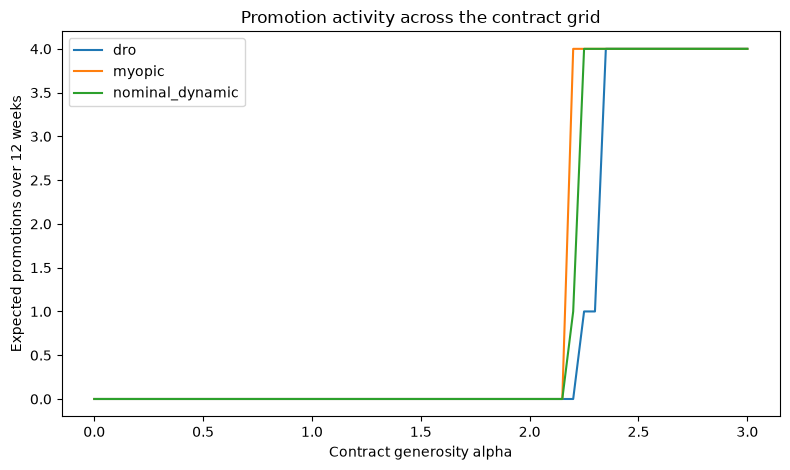

Saved: C:\Users\janza\price-of-extrapolation\results\figures\contract_threshold_promotion_count.png


In [18]:
fig, ax = plt.subplots(
    figsize=(8, 4.8)
)

for policy_name, group in (
    performance.groupby(
        "policy",
        observed=True,
    )
):
    ax.plot(
        group[
            "alpha"
        ],
        group[
            "mean_promotion_count"
        ],
        label=policy_name,
    )

ax.set_xlabel(
    "Contract generosity alpha"
)
ax.set_ylabel(
    "Expected promotions over 12 weeks"
)
ax.set_title(
    "Promotion activity across the contract grid"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    PROMOTION_COUNT_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved:",
    PROMOTION_COUNT_FIGURE_PATH,
)

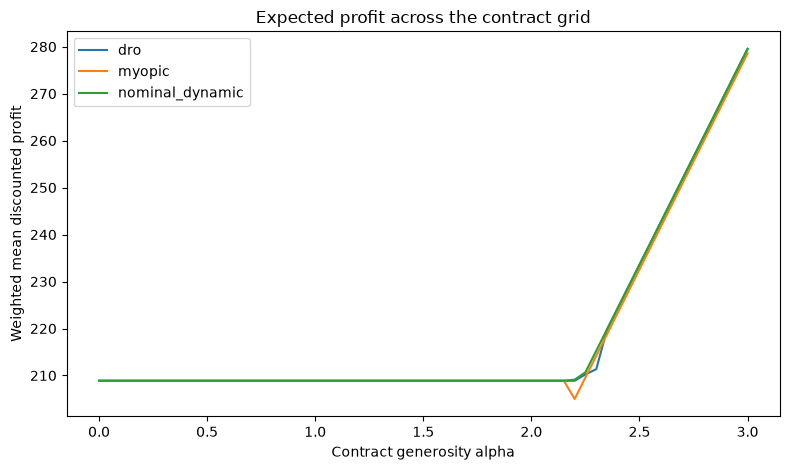

Saved: C:\Users\janza\price-of-extrapolation\results\figures\contract_threshold_mean_profit.png


In [19]:
fig, ax = plt.subplots(
    figsize=(8, 4.8)
)

for policy_name, group in (
    performance.groupby(
        "policy",
        observed=True,
    )
):
    ax.plot(
        group[
            "alpha"
        ],
        group[
            "mean_profit"
        ],
        label=policy_name,
    )

ax.set_xlabel(
    "Contract generosity alpha"
)
ax.set_ylabel(
    "Weighted mean discounted profit"
)
ax.set_title(
    "Expected profit across the contract grid"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    PROFIT_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved:",
    PROFIT_FIGURE_PATH,
)

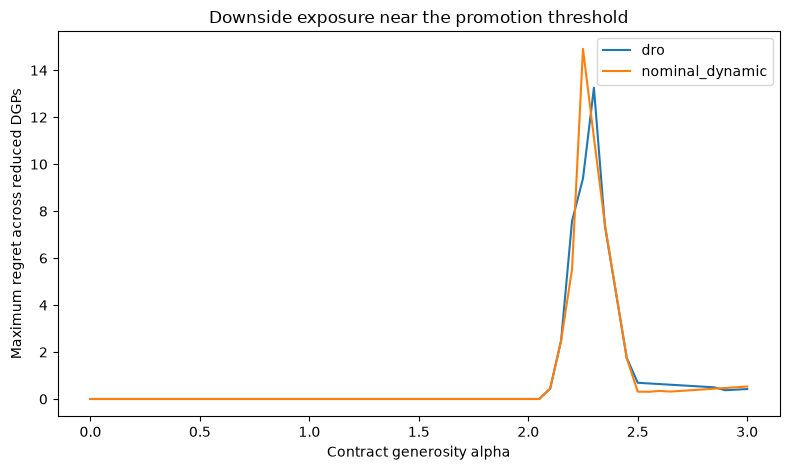

Saved: C:\Users\janza\price-of-extrapolation\results\figures\contract_threshold_maximum_regret.png


In [20]:
fig, ax = plt.subplots(
    figsize=(8, 4.8)
)

for policy_name, group in (
    performance.loc[
        performance[
            "policy"
        ].isin(
            [
                "nominal_dynamic",
                "dro",
            ]
        )
    ]
    .groupby(
        "policy",
        observed=True,
    )
):
    ax.plot(
        group[
            "alpha"
        ],
        group[
            "maximum_regret"
        ],
        label=policy_name,
    )

ax.set_xlabel(
    "Contract generosity alpha"
)
ax.set_ylabel(
    "Maximum regret across reduced DGPs"
)
ax.set_title(
    "Downside exposure near the promotion threshold"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    REGRET_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved:",
    REGRET_FIGURE_PATH,
)

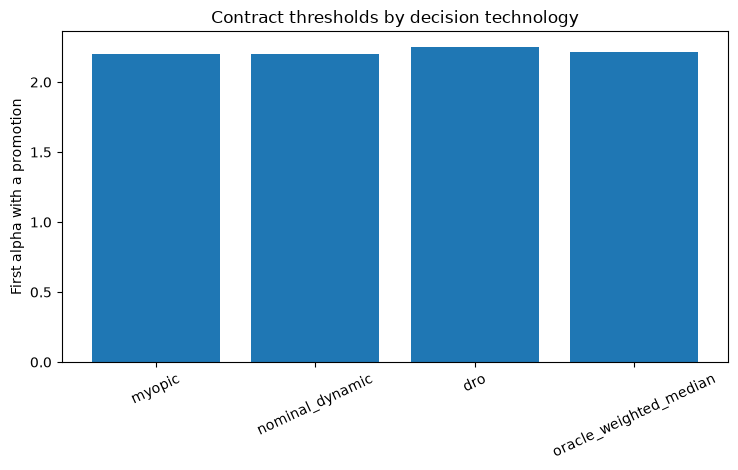

Saved: C:\Users\janza\price-of-extrapolation\results\figures\contract_threshold_summary.png


In [21]:
threshold_plot = (
    thresholds.loc[
        thresholds[
            "decision_rule"
        ].isin(
            [
                "myopic",
                "nominal_dynamic",
                "dro",
                "oracle_weighted_median",
            ]
        )
    ]
    .dropna(
        subset=[
            "alpha_threshold"
        ]
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(7.5, 4.8)
)

ax.bar(
    threshold_plot[
        "decision_rule"
    ],
    threshold_plot[
        "alpha_threshold"
    ],
)

ax.set_ylabel(
    "First alpha with a promotion"
)
ax.set_title(
    "Contract thresholds by decision technology"
)
ax.tick_params(
    axis="x",
    rotation=25,
)
fig.tight_layout()
fig.savefig(
    THRESHOLD_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved:",
    THRESHOLD_FIGURE_PATH,
)

## 18. Monotonicity and decision-relevance diagnostics

In [22]:
diagnostic_rows = []

for policy_name in [
    "myopic",
    "nominal_dynamic",
    "dro",
]:
    group = (
        performance.loc[
            performance[
                "policy"
            ].eq(
                policy_name
            )
        ]
        .sort_values(
            "alpha"
        )
    )

    promotion_indicator = (
        group[
            "promotion_DGP_share"
        ].gt(0)
        .astype(int)
        .to_numpy()
    )

    promotion_count = (
        group[
            "mean_promotion_count"
        ].to_numpy(dtype=float)
    )

    diagnostic_rows.append(
        {
            "policy": policy_name,
            "promotion_indicator_decreases": int(
                np.sum(
                    np.diff(
                        promotion_indicator
                    )
                    < 0
                )
            ),
            "promotion_count_decreases": int(
                np.sum(
                    np.diff(
                        promotion_count
                    )
                    < -1e-10
                )
            ),
            "unique_promotion_count_levels": int(
                np.unique(
                    np.round(
                        promotion_count,
                        8,
                    )
                ).size
            ),
        }
    )

diagnostics = pd.DataFrame(
    diagnostic_rows
)

display(
    diagnostics
)

disagreement_points = int(
    divergence_grid[
        "divergence_type"
    ].ne(
        "same"
    ).sum()
)

print(
    "Nominal–DRO disagreement grid points:",
    disagreement_points,
)

if disagreement_points == 0:
    warnings.warn(
        "Nominal and DRO policies do not diverge anywhere "
        "on the tested contract grid. Behavioral uncertainty "
        "is not decision-relevant for this formulation."
    )

if thresholds.loc[
    thresholds[
        "decision_rule"
    ].eq(
        "dro"
    ),
    "alpha_threshold",
].isna().all():
    warnings.warn(
        "The DRO policy never promotes within the tested "
        "alpha range. Increase ALPHA_MAX only after checking "
        "that the resulting support is economically plausible."
    )

,policy,promotion_indicator_decreases,promotion_count_decreases,unique_promotion_count_levels
0,myopic,0,0,2
1,nominal_dynamic,0,0,3
2,dro,0,0,3


Nominal–DRO disagreement grid points: 5


## 19. Save outputs

In [23]:
policy_grid.to_csv(
    POLICY_GRID_PATH,
    index=False,
)

thresholds.to_csv(
    THRESHOLD_PATH,
    index=False,
)

oracle_threshold_distribution.to_csv(
    ORACLE_THRESHOLD_PATH,
    index=False,
)

divergence_regions.to_csv(
    DIVERGENCE_PATH,
    index=False,
)

performance.to_csv(
    PERFORMANCE_PATH,
    index=False,
)

empirical_comparison.to_csv(
    EMPIRICAL_COMPARISON_PATH,
    index=False,
)

policy_artifact = {
    "alpha_grid": ALPHA_GRID,
    "calibrated_rho": CALIBRATED_RHO,
    "inventory_grid": INVENTORY_GRID,
    "cooldown_states": COOLDOWN_STATES,
    "discount_actions": DISCOUNT_ACTIONS,
    "myopic_policies": myopic_policies,
    "nominal_solutions": nominal_solutions,
    "dro_solutions": dro_solutions,
    "thresholds": thresholds,
    "divergence_regions": divergence_regions,
}

pd.to_pickle(
    policy_artifact,
    POLICY_ARTIFACT_PATH,
)

configuration = {
    "contract_support": (
        "s_alpha(d)=alpha*d"
    ),
    "alpha_min": float(
        ALPHA_MIN
    ),
    "alpha_max": float(
        ALPHA_MAX
    ),
    "alpha_step": float(
        ALPHA_STEP
    ),
    "horizon": int(
        HORIZON
    ),
    "discount_factor": float(
        DISCOUNT_FACTOR
    ),
    "discount_actions": (
        DISCOUNT_ACTIONS.tolist()
    ),
    "minimum_nonpromotion_weeks_after_promotion": int(
        MIN_NONPROMOTION_WEEKS_AFTER_PROMOTION
    ),
    "calibrated_rho": float(
        CALIBRATED_RHO
    ),
    "dro_scenarios": int(
        len(scenarios)
    ),
    "ambiguity_geometry": (
        "finite_support_wasserstein_1_"
        "rectangular_by_period"
    ),
    "behavioral_model": (
        "Q0*(1-d)^(-epsilon)*"
        "exp(gamma*1[d>0]-psi*I);"
        "I_next=r*I+d"
    ),
    "economic_interpretation": (
        "alpha_is_an_exogenous_manufacturer_contract_parameter;"
        "empirical_support_is_only_a_descriptive_benchmark"
    ),
}

CONFIGURATION_PATH.write_text(
    json.dumps(
        configuration,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "Saved policy grid:",
    POLICY_GRID_PATH,
)
print(
    "Saved thresholds:",
    THRESHOLD_PATH,
)
print(
    "Saved divergence regions:",
    DIVERGENCE_PATH,
)
print(
    "Saved policy artifact:",
    POLICY_ARTIFACT_PATH,
)

Saved policy grid: C:\Users\janza\price-of-extrapolation\results\tables\contract_threshold_policy_grid.csv
Saved thresholds: C:\Users\janza\price-of-extrapolation\results\tables\contract_thresholds.csv
Saved divergence regions: C:\Users\janza\price-of-extrapolation\results\tables\contract_policy_divergence_regions.csv
Saved policy artifact: C:\Users\janza\price-of-extrapolation\data\processed\contract_threshold_policy_artifact.pkl


## Interpretation checklist

1. The relevant result is the threshold region, not the largest value
   of \(\alpha\).
2. The one-period break-even threshold is only a benchmark; the dynamic
   threshold incorporates future displacement.
3. A region with nominal promotion and DRO waiting demonstrates the
   economic value of robustness.
4. A region where both promote but choose different depths or timing is
   also decision-relevant.
5. If nominal and DRO coincide over the full grid, the current behavioral
   uncertainty is not economically important enough to support a DRO
   contribution.
6. Oracle thresholds should be reported as a distribution across
   behavioral DGPs, not as one scalar.
7. The empirical support schedule is a descriptive benchmark and may
   omit lump-sum or retrospective manufacturer payments.
8. Extending \(\alpha\) beyond the tested range is justified only when
   the implied monetary support remains economically plausible.
9. Profit values are model-based counterfactuals, not realized causal
   effects.

# Refined contract-threshold analysis

The broad grid established that the economically active region is
approximately

\[
\alpha\in[2.10,2.50].
\]

This section refines that region using increments of \(0.005\). It
estimates:

- precise myopic, nominal, and DRO promotion thresholds;
- the interval over which nominal and DRO realized paths differ;
- the weighted distribution of oracle thresholds;
- profit and regret at the economically relevant change points.

The broad grid remains useful for global context. This refined section
is intended to produce the final threshold table and figure.

## 20. Fine-grid configuration

In [24]:
FINE_ALPHA_MIN = 2.10
FINE_ALPHA_MAX = 2.50
FINE_ALPHA_STEP = 0.005

FINE_ALPHA_GRID = np.round(
    np.arange(
        FINE_ALPHA_MIN,
        FINE_ALPHA_MAX
        + 0.5 * FINE_ALPHA_STEP,
        FINE_ALPHA_STEP,
    ),
    10,
)

FINE_POLICY_GRID_PATH = (
    TABLE_DIR
    / "contract_threshold_policy_grid_refined.csv"
)
FINE_THRESHOLD_PATH = (
    TABLE_DIR
    / "contract_thresholds_refined.csv"
)
FINE_DIVERGENCE_PATH = (
    TABLE_DIR
    / "contract_policy_divergence_refined.csv"
)
FINE_ORACLE_THRESHOLD_PATH = (
    TABLE_DIR
    / "contract_oracle_thresholds_refined.csv"
)
FINE_KEY_PERFORMANCE_PATH = (
    TABLE_DIR
    / "contract_key_point_performance_refined.csv"
)

FINE_PROMOTION_FIGURE_PATH = (
    FIGURE_DIR
    / "contract_threshold_promotion_count_refined.png"
)
FINE_DIVERGENCE_FIGURE_PATH = (
    FIGURE_DIR
    / "contract_nominal_dro_divergence_refined.png"
)
FINE_THRESHOLD_FIGURE_PATH = (
    FIGURE_DIR
    / "contract_threshold_summary_refined.png"
)

FINE_POLICY_ARTIFACT_PATH = (
    PROCESSED_DIR
    / "contract_threshold_policy_artifact_refined.pkl"
)

print(
    "Fine alpha grid:",
    f"{FINE_ALPHA_GRID[0]:.3f}",
    "to",
    f"{FINE_ALPHA_GRID[-1]:.3f}",
    "with",
    len(FINE_ALPHA_GRID),
    "points.",
)

Fine alpha grid: 2.100 to 2.500 with 81 points.


## 21. Solve the three decision technologies on the fine grid

In [25]:
fine_myopic_policies = {}
fine_nominal_solutions = {}
fine_dro_solutions = {}

for alpha_index, alpha in enumerate(
    FINE_ALPHA_GRID,
    start=1,
):
    alpha = float(alpha)

    fine_myopic_policies[
        alpha
    ] = solve_myopic_policy(
        alpha
    )

    fine_nominal_solutions[
        alpha
    ] = solve_dynamic_policy(
        alpha=alpha,
        rho=0.0,
    )

    fine_dro_solutions[
        alpha
    ] = solve_dynamic_policy(
        alpha=alpha,
        rho=CALIBRATED_RHO,
    )

    if (
        alpha_index == 1
        or alpha_index % 10 == 0
        or alpha_index
        == len(FINE_ALPHA_GRID)
    ):
        print(
            f"Solved {alpha_index}/"
            f"{len(FINE_ALPHA_GRID)} "
            f"fine-grid points; "
            f"alpha={alpha:.3f}"
        )

print(
    "Fine-grid policy solution complete."
)

Solved 1/81 fine-grid points; alpha=2.100
Solved 10/81 fine-grid points; alpha=2.145
Solved 20/81 fine-grid points; alpha=2.195
Solved 30/81 fine-grid points; alpha=2.245
Solved 40/81 fine-grid points; alpha=2.295
Solved 50/81 fine-grid points; alpha=2.345
Solved 60/81 fine-grid points; alpha=2.395
Solved 70/81 fine-grid points; alpha=2.445
Solved 80/81 fine-grid points; alpha=2.495
Solved 81/81 fine-grid points; alpha=2.500
Fine-grid policy solution complete.


## 22. Evaluate realized paths under the reduced behavioral DGPs

In [26]:
fine_rows = []
fine_divergence_rows = []

for alpha in FINE_ALPHA_GRID:
    alpha = float(alpha)

    policies = {
        "myopic": (
            fine_myopic_policies[
                alpha
            ]
        ),
        "nominal_dynamic": (
            fine_nominal_solutions[
                alpha
            ]["policy"]
        ),
        "dro": (
            fine_dro_solutions[
                alpha
            ]["policy"]
        ),
    }

    nominal_dro_disagreement_weight = 0.0
    nominal_promotes_dro_waits_weight = 0.0
    dro_promotes_nominal_waits_weight = 0.0

    for scenario_id, (
        parameters,
        scenario_weight,
    ) in enumerate(
        zip(
            scenario_parameters,
            scenario_weights,
        )
    ):
        scenario_results = {}

        for policy_name, policy in (
            policies.items()
        ):
            result = evaluate_policy(
                policy,
                parameters,
                alpha,
            )
            scenario_results[
                policy_name
            ] = result

            fine_rows.append(
                {
                    "alpha": alpha,
                    "scenario_id": (
                        scenario_id
                    ),
                    "scenario_weight": float(
                        scenario_weight
                    ),
                    "policy": (
                        policy_name
                    ),
                    "discounted_profit": (
                        result[
                            "discounted_profit"
                        ]
                    ),
                    "promotion_count": (
                        result[
                            "promotion_count"
                        ]
                    ),
                    "mean_promotion_depth": (
                        result[
                            "mean_promotion_depth"
                        ]
                    ),
                    "first_promotion_week": (
                        result[
                            "first_promotion_week"
                        ]
                    ),
                    "discount_path": (
                        tuple(
                            result[
                                "discount_path"
                            ]
                        )
                    ),
                }
            )

        nominal_path = tuple(
            scenario_results[
                "nominal_dynamic"
            ][
                "discount_path"
            ]
        )
        dro_path = tuple(
            scenario_results[
                "dro"
            ][
                "discount_path"
            ]
        )

        nominal_promotes = (
            scenario_results[
                "nominal_dynamic"
            ][
                "promotion_count"
            ]
            > 0
        )
        dro_promotes = (
            scenario_results[
                "dro"
            ][
                "promotion_count"
            ]
            > 0
        )

        if nominal_path != dro_path:
            nominal_dro_disagreement_weight += (
                float(
                    scenario_weight
                )
            )

        if (
            nominal_promotes
            and not dro_promotes
        ):
            nominal_promotes_dro_waits_weight += (
                float(
                    scenario_weight
                )
            )

        if (
            dro_promotes
            and not nominal_promotes
        ):
            dro_promotes_nominal_waits_weight += (
                float(
                    scenario_weight
                )
            )

    fine_divergence_rows.append(
        {
            "alpha": alpha,
            "realized_path_disagreement_share": (
                nominal_dro_disagreement_weight
            ),
            "nominal_promotes_dro_waits_share": (
                nominal_promotes_dro_waits_weight
            ),
            "dro_promotes_nominal_waits_share": (
                dro_promotes_nominal_waits_weight
            ),
            "policy_tensor_equal": bool(
                np.array_equal(
                    policies[
                        "nominal_dynamic"
                    ],
                    policies[
                        "dro"
                    ],
                )
            ),
        }
    )

fine_policy_grid = pd.DataFrame(
    fine_rows
)
fine_divergence = pd.DataFrame(
    fine_divergence_rows
)

print(
    "Fine-grid realized-path rows:",
    f"{len(fine_policy_grid):,}",
)

Fine-grid realized-path rows: 9,720


## 23. Compute weighted fine-grid summaries and exact policy thresholds

In [27]:
fine_summary_rows = []

for (
    alpha,
    policy_name,
), group in fine_policy_grid.groupby(
    [
        "alpha",
        "policy",
    ],
    observed=True,
):
    weights = group[
        "scenario_weight"
    ].to_numpy(dtype=float)

    profit = group[
        "discounted_profit"
    ].to_numpy(dtype=float)

    promotion_count = group[
        "promotion_count"
    ].to_numpy(dtype=float)

    mean_depth = group[
        "mean_promotion_depth"
    ].to_numpy(dtype=float)

    first_week = group[
        "first_promotion_week"
    ].to_numpy(dtype=float)

    fine_summary_rows.append(
        {
            "alpha": float(
                alpha
            ),
            "policy": str(
                policy_name
            ),
            "mean_profit": (
                weighted_mean(
                    profit,
                    weights,
                )
            ),
            "p10_profit": (
                weighted_quantile(
                    profit,
                    weights,
                    0.10,
                )
            ),
            "mean_promotion_count": (
                weighted_mean(
                    promotion_count,
                    weights,
                )
            ),
            "mean_promotion_depth": (
                weighted_mean(
                    mean_depth,
                    weights,
                )
            ),
            "promotion_DGP_share": (
                weighted_mean(
                    (
                        promotion_count
                        > 0
                    ).astype(float),
                    weights,
                )
            ),
            "median_first_promotion_week": (
                weighted_quantile(
                    first_week,
                    weights,
                    0.50,
                )
            ),
        }
    )

fine_summary = pd.DataFrame(
    fine_summary_rows
)

fine_threshold_rows = []

for policy_name in [
    "myopic",
    "nominal_dynamic",
    "dro",
]:
    policy_summary = (
        fine_summary.loc[
            fine_summary[
                "policy"
            ].eq(
                policy_name
            )
        ]
        .sort_values(
            "alpha"
        )
    )

    promoting = (
        policy_summary[
            "promotion_DGP_share"
        ].gt(0)
    )

    threshold = (
        float(
            policy_summary.loc[
                promoting,
                "alpha",
            ].min()
        )
        if promoting.any()
        else np.nan
    )

    fine_threshold_rows.append(
        {
            "decision_rule": (
                policy_name
            ),
            "alpha_threshold": (
                threshold
            ),
            "grid_resolution": (
                FINE_ALPHA_STEP
            ),
            "threshold_found": bool(
                promoting.any()
            ),
        }
    )

fine_thresholds = pd.DataFrame(
    fine_threshold_rows
)

display(
    fine_thresholds
)

,decision_rule,alpha_threshold,grid_resolution,threshold_found
0,myopic,2.19,0.005,True
1,nominal_dynamic,2.19,0.005,True
2,dro,2.24,0.005,True


## 24. Extract contiguous nominal–DRO disagreement regions

In [28]:
fine_divergence[
    "divergence_type"
] = "same_realized_path"

fine_divergence.loc[
    fine_divergence[
        "nominal_promotes_dro_waits_share"
    ].gt(0),
    "divergence_type",
] = "nominal_promotes_dro_waits"

fine_divergence.loc[
    fine_divergence[
        "dro_promotes_nominal_waits_share"
    ].gt(0),
    "divergence_type",
] = "dro_promotes_nominal_waits"

fine_divergence.loc[
    fine_divergence[
        "realized_path_disagreement_share"
    ].gt(0)
    & fine_divergence[
        "nominal_promotes_dro_waits_share"
    ].eq(0)
    & fine_divergence[
        "dro_promotes_nominal_waits_share"
    ].eq(0),
    "divergence_type",
] = "both_promote_different_path"

ordered_divergence = (
    fine_divergence.sort_values(
        "alpha"
    )
    .reset_index(drop=True)
)

region_id = (
    ordered_divergence[
        "divergence_type"
    ]
    .ne(
        ordered_divergence[
            "divergence_type"
        ].shift()
    )
    .cumsum()
)

fine_divergence_regions = (
    ordered_divergence.groupby(
        region_id,
        observed=True,
    )
    .agg(
        divergence_type=(
            "divergence_type",
            "first",
        ),
        alpha_start=(
            "alpha",
            "min",
        ),
        alpha_end=(
            "alpha",
            "max",
        ),
        grid_points=(
            "alpha",
            "size",
        ),
        maximum_disagreement_share=(
            "realized_path_disagreement_share",
            "max",
        ),
    )
    .reset_index(
        drop=True
    )
)

display(
    fine_divergence_regions
)

,divergence_type,alpha_start,alpha_end,grid_points,maximum_disagreement_share
0,same_realized_path,2.10,2.185,18,0.0
1,nominal_promotes_dro_waits,2.19,2.235,10,1.0
2,both_promote_different_path,2.24,2.500,53,1.0


## 25. Estimate the oracle threshold distribution by discrete bisection

In [29]:
def oracle_promotes_at_alpha(
    parameters: BehavioralParameters,
    alpha: float,
    cache: dict[float, bool],
) -> bool:
    alpha = float(
        alpha
    )

    if alpha not in cache:
        oracle_policy = (
            solve_oracle_policy(
                parameters,
                alpha,
            )
        )

        oracle_result = (
            evaluate_policy(
                oracle_policy,
                parameters,
                alpha,
            )
        )

        cache[alpha] = bool(
            oracle_result[
                "promotion_count"
            ]
            > 0
        )

    return cache[
        alpha
    ]


def discrete_oracle_threshold(
    parameters: BehavioralParameters,
) -> tuple[
    float,
    int,
    bool,
]:
    cache: dict[float, bool] = {}

    low_index = 0
    high_index = (
        len(
            FINE_ALPHA_GRID
        )
        - 1
    )

    promotes_low = (
        oracle_promotes_at_alpha(
            parameters,
            float(
                FINE_ALPHA_GRID[
                    low_index
                ]
            ),
            cache,
        )
    )

    if promotes_low:
        return (
            float(
                FINE_ALPHA_GRID[
                    low_index
                ]
            ),
            len(cache),
            True,
        )

    promotes_high = (
        oracle_promotes_at_alpha(
            parameters,
            float(
                FINE_ALPHA_GRID[
                    high_index
                ]
            ),
            cache,
        )
    )

    if not promotes_high:
        return (
            np.nan,
            len(cache),
            True,
        )

    while (
        high_index
        - low_index
        > 1
    ):
        middle_index = (
            low_index
            + high_index
        ) // 2

        promotes_middle = (
            oracle_promotes_at_alpha(
                parameters,
                float(
                    FINE_ALPHA_GRID[
                        middle_index
                    ]
                ),
                cache,
            )
        )

        if promotes_middle:
            high_index = (
                middle_index
            )
        else:
            low_index = (
                middle_index
            )

    threshold = float(
        FINE_ALPHA_GRID[
            high_index
        ]
    )

    # Local monotonicity check around the located threshold.
    previous_promotes = (
        oracle_promotes_at_alpha(
            parameters,
            float(
                FINE_ALPHA_GRID[
                    high_index - 1
                ]
            ),
            cache,
        )
    )

    threshold_promotes = (
        oracle_promotes_at_alpha(
            parameters,
            threshold,
            cache,
        )
    )

    local_monotonicity_ok = bool(
        (not previous_promotes)
        and threshold_promotes
    )

    return (
        threshold,
        len(cache),
        local_monotonicity_ok,
    )


fine_oracle_rows = []

for scenario_id, (
    parameters,
    scenario_weight,
) in enumerate(
    zip(
        scenario_parameters,
        scenario_weights,
    )
):
    (
        threshold,
        oracle_solves,
        monotonicity_ok,
    ) = discrete_oracle_threshold(
        parameters
    )

    fine_oracle_rows.append(
        {
            "scenario_id": (
                scenario_id
            ),
            "scenario_weight": float(
                scenario_weight
            ),
            "oracle_alpha_threshold": (
                threshold
            ),
            "oracle_policy_solves": (
                oracle_solves
            ),
            "local_monotonicity_ok": (
                monotonicity_ok
            ),
            **{
                column: getattr(
                    parameters,
                    column,
                )
                for column in (
                    PARAMETER_COLUMNS
                )
            },
        }
    )

fine_oracle_thresholds = (
    pd.DataFrame(
        fine_oracle_rows
    )
)

oracle_threshold_values = (
    fine_oracle_thresholds[
        "oracle_alpha_threshold"
    ].to_numpy(
        dtype=float
    )
)
oracle_threshold_weights = (
    fine_oracle_thresholds[
        "scenario_weight"
    ].to_numpy(
        dtype=float
    )
)

oracle_summary = pd.DataFrame(
    [
        {
            "decision_rule": (
                "oracle_weighted_p10"
            ),
            "alpha_threshold": (
                weighted_quantile(
                    oracle_threshold_values,
                    oracle_threshold_weights,
                    0.10,
                )
            ),
        },
        {
            "decision_rule": (
                "oracle_weighted_median"
            ),
            "alpha_threshold": (
                weighted_quantile(
                    oracle_threshold_values,
                    oracle_threshold_weights,
                    0.50,
                )
            ),
        },
        {
            "decision_rule": (
                "oracle_weighted_p90"
            ),
            "alpha_threshold": (
                weighted_quantile(
                    oracle_threshold_values,
                    oracle_threshold_weights,
                    0.90,
                )
            ),
        },
    ]
)

refined_threshold_summary = pd.concat(
    [
        fine_thresholds[
            [
                "decision_rule",
                "alpha_threshold",
            ]
        ],
        oracle_summary,
    ],
    ignore_index=True,
)

display(
    refined_threshold_summary
)

print(
    "Oracle local monotonicity checks passed:",
    f"{fine_oracle_thresholds['local_monotonicity_ok'].mean():.2%}",
)
print(
    "Mean oracle DP solves per DGP:",
    f"{fine_oracle_thresholds['oracle_policy_solves'].mean():.2f}",
)

,decision_rule,alpha_threshold
0,myopic,2.190000
1,nominal_dynamic,2.190000
2,dro,2.240000
3,oracle_weighted_p10,2.100000
4,oracle_weighted_median,2.196739
5,oracle_weighted_p90,2.259167


Oracle local monotonicity checks passed: 100.00%
Mean oracle DP solves per DGP: 7.17


## 26. Evaluate regret at economically relevant contract points

In [30]:
relevant_alpha_values = {
    2.20,
    2.25,
    2.40,
    2.45,
}

relevant_alpha_values.update(
    fine_thresholds[
        "alpha_threshold"
    ].dropna().tolist()
)

for row in (
    fine_divergence_regions.itertuples(
        index=False
    )
):
    relevant_alpha_values.add(
        float(
            row.alpha_start
        )
    )
    relevant_alpha_values.add(
        float(
            row.alpha_end
        )
    )

expanded_alpha_values = set()

for alpha in (
    relevant_alpha_values
):
    for offset in [
        -FINE_ALPHA_STEP,
        0.0,
        FINE_ALPHA_STEP,
    ]:
        candidate = float(
            np.round(
                alpha
                + offset,
                10,
            )
        )

        if (
            FINE_ALPHA_MIN
            <= candidate
            <= FINE_ALPHA_MAX
        ):
            nearest_alpha = float(
                FINE_ALPHA_GRID[
                    np.argmin(
                        np.abs(
                            FINE_ALPHA_GRID
                            - candidate
                        )
                    )
                ]
            )
            expanded_alpha_values.add(
                nearest_alpha
            )

key_alpha_values = sorted(
    expanded_alpha_values
)

key_rows = []

for alpha in key_alpha_values:
    policies = {
        "myopic": (
            fine_myopic_policies[
                alpha
            ]
        ),
        "nominal_dynamic": (
            fine_nominal_solutions[
                alpha
            ][
                "policy"
            ]
        ),
        "dro": (
            fine_dro_solutions[
                alpha
            ][
                "policy"
            ]
        ),
    }

    for scenario_id, (
        parameters,
        scenario_weight,
    ) in enumerate(
        zip(
            scenario_parameters,
            scenario_weights,
        )
    ):
        oracle_policy = (
            solve_oracle_policy(
                parameters,
                alpha,
            )
        )

        oracle_result = (
            evaluate_policy(
                oracle_policy,
                parameters,
                alpha,
            )
        )

        oracle_profit = float(
            oracle_result[
                "discounted_profit"
            ]
        )

        for policy_name, policy in (
            policies.items()
        ):
            result = evaluate_policy(
                policy,
                parameters,
                alpha,
            )

            key_rows.append(
                {
                    "alpha": alpha,
                    "scenario_id": (
                        scenario_id
                    ),
                    "scenario_weight": float(
                        scenario_weight
                    ),
                    "policy": (
                        policy_name
                    ),
                    "discounted_profit": (
                        result[
                            "discounted_profit"
                        ]
                    ),
                    "oracle_profit": (
                        oracle_profit
                    ),
                    "regret": (
                        oracle_profit
                        - result[
                            "discounted_profit"
                        ]
                    ),
                    "promotion_count": (
                        result[
                            "promotion_count"
                        ]
                    ),
                    "mean_promotion_depth": (
                        result[
                            "mean_promotion_depth"
                        ]
                    ),
                    "first_promotion_week": (
                        result[
                            "first_promotion_week"
                        ]
                    ),
                }
            )

key_evaluation = pd.DataFrame(
    key_rows
)

key_summary_rows = []

for (
    alpha,
    policy_name,
), group in key_evaluation.groupby(
    [
        "alpha",
        "policy",
    ],
    observed=True,
):
    weights = group[
        "scenario_weight"
    ].to_numpy(dtype=float)

    profit = group[
        "discounted_profit"
    ].to_numpy(dtype=float)

    regret = group[
        "regret"
    ].to_numpy(dtype=float)

    promotions = group[
        "promotion_count"
    ].to_numpy(dtype=float)

    key_summary_rows.append(
        {
            "alpha": float(
                alpha
            ),
            "policy": str(
                policy_name
            ),
            "mean_profit": (
                weighted_mean(
                    profit,
                    weights,
                )
            ),
            "p10_profit": (
                weighted_quantile(
                    profit,
                    weights,
                    0.10,
                )
            ),
            "mean_regret": (
                weighted_mean(
                    regret,
                    weights,
                )
            ),
            "p90_regret": (
                weighted_quantile(
                    regret,
                    weights,
                    0.90,
                )
            ),
            "maximum_regret": float(
                regret.max()
            ),
            "mean_promotion_count": (
                weighted_mean(
                    promotions,
                    weights,
                )
            ),
        }
    )

key_performance = pd.DataFrame(
    key_summary_rows
)

display(
    key_performance
)

,alpha,policy,mean_profit,p10_profit,mean_regret,p90_regret,maximum_regret,mean_promotion_count
0,2.100,dro,208.880018,208.880018,0.030515,0.132925,0.442272,0.0
1,2.100,myopic,208.880018,208.880018,0.030515,0.132925,0.442272,0.0
2,2.100,nominal_dynamic,208.880018,208.880018,0.030515,0.132925,0.442272,0.0
3,2.105,dro,208.880018,208.880018,0.040439,0.163889,0.550300,0.0
4,2.105,myopic,208.880018,208.880018,0.040439,0.163889,0.550300,0.0
...,...,...,...,...,...,...,...,...
61,2.495,myopic,232.129392,221.726869,1.048921,2.154888,3.079573,4.0
62,2.495,nominal_dynamic,233.155915,223.796767,0.022398,0.085364,0.315033,4.0
63,2.500,dro,233.546527,224.193619,0.090889,0.166638,0.690909,4.0
64,2.500,myopic,232.589298,222.159806,1.048119,2.154512,3.079317,4.0


## 27. Final refined figures

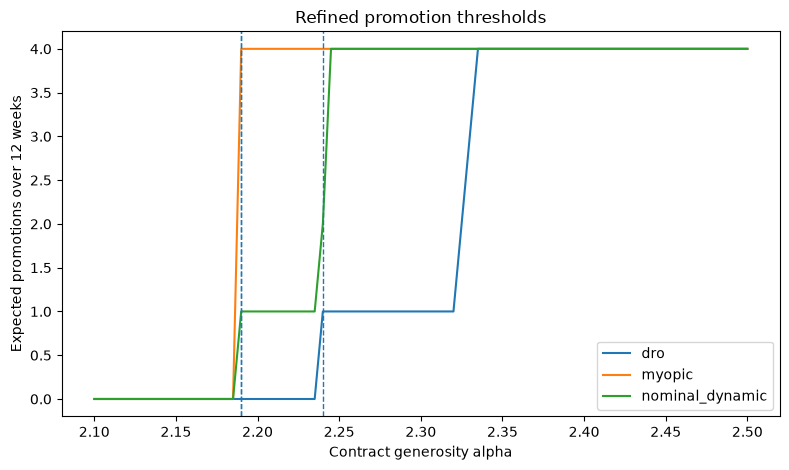

Saved: C:\Users\janza\price-of-extrapolation\results\figures\contract_threshold_promotion_count_refined.png


In [31]:
fig, ax = plt.subplots(
    figsize=(8, 4.8)
)

for policy_name, group in (
    fine_summary.groupby(
        "policy",
        observed=True,
    )
):
    ax.plot(
        group[
            "alpha"
        ],
        group[
            "mean_promotion_count"
        ],
        label=policy_name,
    )

for row in (
    fine_thresholds.itertuples(
        index=False
    )
):
    if np.isfinite(
        row.alpha_threshold
    ):
        ax.axvline(
            row.alpha_threshold,
            linestyle="--",
            linewidth=1.0,
        )

ax.set_xlabel(
    "Contract generosity alpha"
)
ax.set_ylabel(
    "Expected promotions over 12 weeks"
)
ax.set_title(
    "Refined promotion thresholds"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    FINE_PROMOTION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved:",
    FINE_PROMOTION_FIGURE_PATH,
)

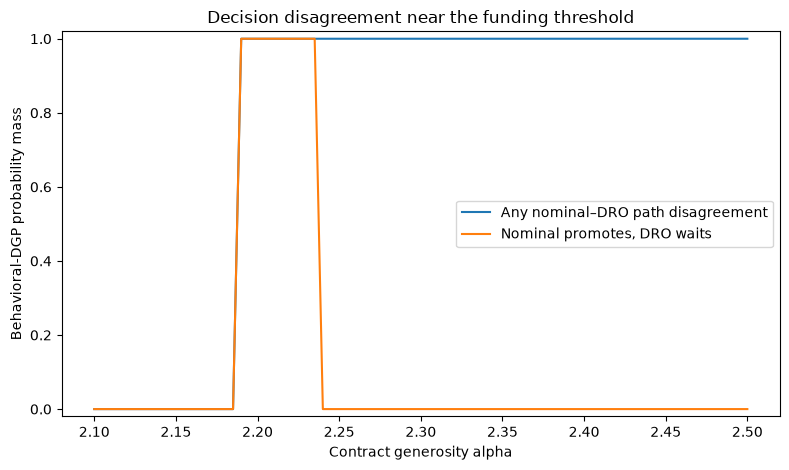

Saved: C:\Users\janza\price-of-extrapolation\results\figures\contract_nominal_dro_divergence_refined.png


In [32]:
fig, ax = plt.subplots(
    figsize=(8, 4.8)
)

ax.plot(
    fine_divergence[
        "alpha"
    ],
    fine_divergence[
        "realized_path_disagreement_share"
    ],
    label=(
        "Any nominal–DRO path disagreement"
    ),
)
ax.plot(
    fine_divergence[
        "alpha"
    ],
    fine_divergence[
        "nominal_promotes_dro_waits_share"
    ],
    label=(
        "Nominal promotes, DRO waits"
    ),
)

ax.set_xlabel(
    "Contract generosity alpha"
)
ax.set_ylabel(
    "Behavioral-DGP probability mass"
)
ax.set_ylim(
    -0.02,
    1.02,
)
ax.set_title(
    "Decision disagreement near the funding threshold"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    FINE_DIVERGENCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved:",
    FINE_DIVERGENCE_FIGURE_PATH,
)

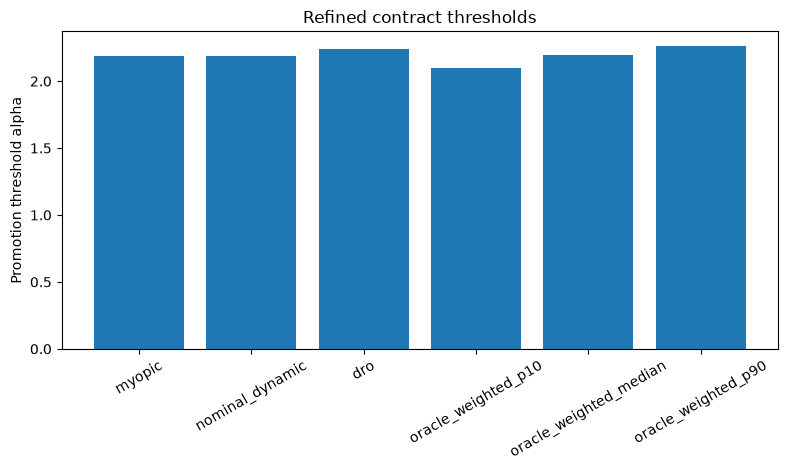

Saved: C:\Users\janza\price-of-extrapolation\results\figures\contract_threshold_summary_refined.png


In [33]:
threshold_plot = (
    refined_threshold_summary.dropna(
        subset=[
            "alpha_threshold"
        ]
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(8, 4.8)
)

ax.bar(
    threshold_plot[
        "decision_rule"
    ],
    threshold_plot[
        "alpha_threshold"
    ],
)

ax.set_ylabel(
    "Promotion threshold alpha"
)
ax.set_title(
    "Refined contract thresholds"
)
ax.tick_params(
    axis="x",
    rotation=30,
)
fig.tight_layout()
fig.savefig(
    FINE_THRESHOLD_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved:",
    FINE_THRESHOLD_FIGURE_PATH,
)

## 28. Save refined outputs

In [34]:
fine_policy_grid.to_csv(
    FINE_POLICY_GRID_PATH,
    index=False,
)

refined_threshold_summary.to_csv(
    FINE_THRESHOLD_PATH,
    index=False,
)

fine_divergence_regions.to_csv(
    FINE_DIVERGENCE_PATH,
    index=False,
)

fine_oracle_thresholds.to_csv(
    FINE_ORACLE_THRESHOLD_PATH,
    index=False,
)

key_performance.to_csv(
    FINE_KEY_PERFORMANCE_PATH,
    index=False,
)

refined_artifact = {
    "fine_alpha_grid": (
        FINE_ALPHA_GRID
    ),
    "fine_alpha_step": (
        FINE_ALPHA_STEP
    ),
    "calibrated_rho": (
        CALIBRATED_RHO
    ),
    "myopic_policies": (
        fine_myopic_policies
    ),
    "nominal_solutions": (
        fine_nominal_solutions
    ),
    "dro_solutions": (
        fine_dro_solutions
    ),
    "threshold_summary": (
        refined_threshold_summary
    ),
    "divergence_regions": (
        fine_divergence_regions
    ),
    "oracle_thresholds": (
        fine_oracle_thresholds
    ),
    "key_performance": (
        key_performance
    ),
}

pd.to_pickle(
    refined_artifact,
    FINE_POLICY_ARTIFACT_PATH,
)

print(
    "Saved refined policy grid:",
    FINE_POLICY_GRID_PATH,
)
print(
    "Saved refined thresholds:",
    FINE_THRESHOLD_PATH,
)
print(
    "Saved refined divergence regions:",
    FINE_DIVERGENCE_PATH,
)
print(
    "Saved refined oracle thresholds:",
    FINE_ORACLE_THRESHOLD_PATH,
)
print(
    "Saved refined policy artifact:",
    FINE_POLICY_ARTIFACT_PATH,
)

Saved refined policy grid: C:\Users\janza\price-of-extrapolation\results\tables\contract_threshold_policy_grid_refined.csv
Saved refined thresholds: C:\Users\janza\price-of-extrapolation\results\tables\contract_thresholds_refined.csv
Saved refined divergence regions: C:\Users\janza\price-of-extrapolation\results\tables\contract_policy_divergence_refined.csv
Saved refined oracle thresholds: C:\Users\janza\price-of-extrapolation\results\tables\contract_oracle_thresholds_refined.csv
Saved refined policy artifact: C:\Users\janza\price-of-extrapolation\data\processed\contract_threshold_policy_artifact_refined.pkl


## Refined-analysis interpretation checklist

1. Threshold precision is limited by the \(0.005\) contract grid.
2. The nominal–DRO disagreement interval should be reported as an
   interval, not reduced to one threshold difference.
3. Oracle thresholds are estimated efficiently by discrete bisection
   and locally checked for monotonicity.
4. Regret is evaluated only at economically relevant change points,
   avoiding thousands of unnecessary oracle DP solves.
5. A narrow disagreement interval can still be economically relevant,
   but its monetary width should be translated into per-unit support
   for each discount depth.
6. If nominal and DRO again coincide throughout the refined grid, the
   apparent broad-grid difference was a discretization artifact.